### Cleaning (`ling_data`)

In [1]:
#setup packages
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadr import read_r
from scipy.stats import chi2_contingency

#notebook settings
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
OI = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9']  #colorblind-safe

#output folders for figures and tables (report)
import os
FIG_DIR = '../report/figures'
TAB_DIR = '../report/tables'
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(TAB_DIR, exist_ok=True)

#load data
question_data = read_r('../data/question_data.RData')
state_df = gpd.read_file('../data/shapefiles')
state_df = state_df[state_df['iso_a2'] == 'US'] #filter for US states

In [2]:
#load and inspect ling data with ZIP as string to preserve leading 0 
ling_raw = pd.read_csv('../data/lingData.txt', sep=r'\s+', dtype={'ZIP': str})
qcols = [c for c in ling_raw.columns if c.startswith('Q')]

print('shape:', ling_raw.shape, '| question columns:', len(qcols))
ling_raw.head()

shape: (47471, 73) | question columns: 67


,ID,CITY,STATE,ZIP,Q050,Q051,Q052,Q053,Q054,Q055,Q056,Q057,Q058,Q059,Q060,...,Q104,Q105,Q106,Q107,Q109,Q110,Q111,Q115,Q117,Q118,Q119,Q120,Q121,lat,long
0,1,Boise,ID,83704,4,1,3,2,3,1,1,2,2,20,8,...,1,5,8,3,1,8,2,1,6,7,3,2,3,43.631230,-116.287161
1,2,Pittsfield,MA,01201,4,2,3,2,2,2,2,1,1,21,8,...,1,1,1,3,1,8,2,1,1,7,1,1,3,42.453840,-73.254003
2,3,Burlington,VT,05401,4,1,2,2,2,2,2,2,3,20,9,...,3,1,1,3,1,4,2,1,4,7,1,2,1,44.484038,-73.221265
3,4,Easton,PA,18042,7,1,1,2,2,2,1,1,2,20,8,...,1,1,3,3,1,8,1,1,3,7,1,2,1,40.681798,-75.220820
4,5,Bedford,MA,01730,8,2,3,1,2,2,2,2,3,2,5,...,1,1,1,3,1,8,3,1,5,8,1,1,1,42.496679,-71.275046


In [3]:
#check dtypes, ID uniqueness, ZIP lengths
print(ling_raw.dtypes.value_counts(), '\n')
print('duplicate IDs:', ling_raw['ID'].duplicated().sum())
print('ZIP length counts (4-digit ZIPs lost their leading 0):')
print(ling_raw['ZIP'].str.len().value_counts())

ling = ling_raw.copy() #make copy for later cleaning edits

int64      68
str         3
float64     2
Name: count, dtype: int64 

duplicate IDs: 0
ZIP length counts (4-digit ZIPs lost their leading 0):
ZIP
5    47471
Name: count, dtype: int64


In [4]:
#check data for zeros, want to convert to NaN so it is not treated as an integer
zero = (ling[qcols] == 0)
print('total zeros:', zero.sum().sum(), f'({zero.values.mean():.1%} of all answers)')
print('NaNs already in Q columns:', ling[qcols].isna().sum().sum())

total zeros: 100902 (3.2% of all answers)
NaNs already in Q columns: 0


In [5]:
#fix: recode 0 -> NaN
ling[qcols] = ling[qcols].replace(0, np.nan)

#check
print('zeros left:', (ling[qcols] == 0).sum().sum(), '| NaNs now:', ling[qcols].isna().sum().sum())

zeros left: 0 | NaNs now: 100902


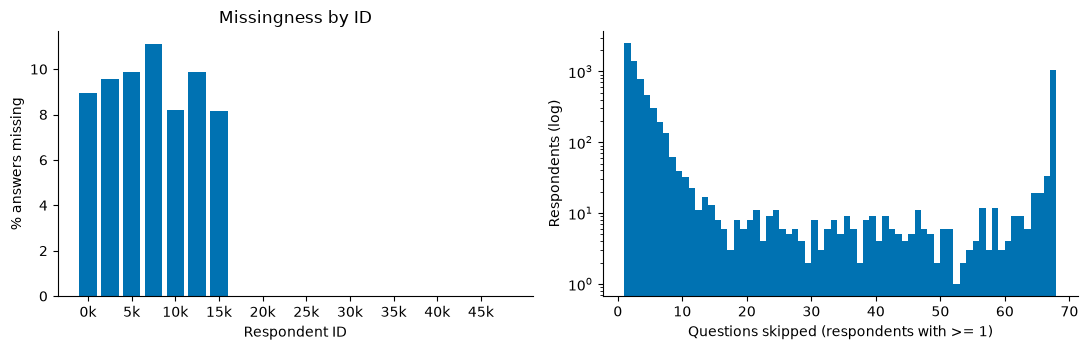

respondents who skipped all 67: 1040


In [6]:
#check missingness of questions
ling['n_skipped'] = ling[qcols].isna().sum(axis=1)
by_id = ling.groupby(pd.cut(ling['ID'], np.arange(0, 50001, 2500)), observed=False)['n_skipped'].mean() / len(qcols)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(range(len(by_id)), by_id.values * 100, color=OI[0])
ax[0].set_xticks(range(0, len(by_id), 2)); ax[0].set_xticklabels([f'{int(i.left/1000)}k' for i in by_id.index][::2])
ax[0].set_xlabel('Respondent ID'); ax[0].set_ylabel('% answers missing'); ax[0].set_title('Missingness by ID')
s = ling.loc[ling['n_skipped'] > 0, 'n_skipped']
ax[1].hist(s, bins=range(1, 69), color=OI[0]); ax[1].set_yscale('log')
ax[1].set_xlabel('Questions skipped (respondents with >= 1)'); ax[1].set_ylabel('Respondents (log)')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/clean_missingness.png', dpi=200, bbox_inches='tight'); plt.show()

print('respondents who skipped all 67:', (ling['n_skipped'] == len(qcols)).sum())

In [7]:
#number of questions skipped
ling['skip_group'] = pd.cut(ling['n_skipped'], [-1, 0, 5, 30, 66, 67], labels=['0', '1-5', '6-30', '31-66', 'all 67'])
print(ling['skip_group'].value_counts().sort_index())

skip_group
0         40061
1-5        5477
6-30        629
31-66       264
all 67     1040
Name: count, dtype: int64


In [8]:
#check missingness of lat/long, CITY, STATE
print(ling[['CITY', 'STATE', 'ZIP', 'lat', 'long']].isna().sum())
print('\nrows with no lat/long that DO have a state:', (ling['lat'].isna() & ling['STATE'].notna()).sum())
print('overlap: no answers AND no lat/long:', ((ling['n_skipped'] == 67) & ling['lat'].isna()).sum())

CITY      540
STATE       3
ZIP         0
lat      1020
long     1020
dtype: int64

rows with no lat/long that DO have a state: 1020
overlap: no answers AND no lat/long: 25


In [9]:
#check STATE column because it is free text, possibly contains invalid values
valid_states = set(state_df['postal']) | {'DC'}
ling['state_valid'] = ling['STATE'].isin(valid_states)
print('invalid STATE rows:', (~ling['state_valid']).sum())
print(ling.loc[~ling['state_valid'], 'STATE'].value_counts(dropna=False).head(15))


invalid STATE rows: 159
STATE
XX     84
IO     10
TE      8
N.      5
NB      4
ON      4
NaN     3
KA      3
HA      2
WN      2
NO      2
MU      2
OM      1
MM      1
NT      1
Name: count, dtype: int64


In [10]:
#check if CITY/STATE agree with lat/long
g = ling.dropna(subset=['lat', 'long'])
med = g.groupby('STATE')[['lat', 'long']].transform('median')
dist = np.hypot(g['lat'] - med['lat'], g['long'] - med['long'])
ling['loc_mismatch'] = False
ling.loc[g.index, 'loc_mismatch'] = (dist > 15) & g['state_valid']
print('state vs lat/long mismatches (>15 deg):', ling['loc_mismatch'].sum())
ling.loc[ling['loc_mismatch'], ['CITY', 'STATE', 'ZIP', 'lat', 'long']].head(10)

state vs lat/long mismatches (>15 deg): 142


,CITY,STATE,ZIP,lat,long
356,sitka,AK,99835,57.064376,-135.322709
494,ElPaso,CA,61738,40.731662,-89.039782
797,NewYork,NY,92651,33.535325,-117.771920
799,NewYork,NY,90028,34.098859,-118.327459
906,Petersburg,AK,99833,56.784206,-132.973541
1188,Chicago,IL,97201,45.498940,-122.687810
1350,St.Louis,MO,94114,37.758434,-122.435126
1576,Memphis,TN,94102,37.779329,-122.419159
1588,newyork,NY,94526,37.811676,-121.986478
1678,Tucson,AR,85710,32.213291,-110.825598


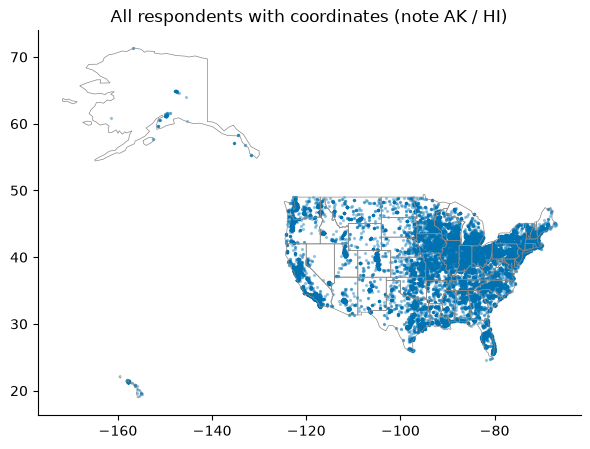

outside contiguous US: 206


In [11]:
#check where are the points are on a map (outside the contiguous US?)
fig, ax = plt.subplots(figsize=(9, 5))
state_df.boundary.plot(ax=ax, color='#888888', linewidth=0.5)
ax.scatter(ling['long'], ling['lat'], s=2, alpha=0.3, color=OI[0])
ax.set_title('All respondents with coordinates (note AK / HI)')
plt.savefig(f'{FIG_DIR}/clean_all_points_map.png', dpi=200, bbox_inches='tight'); plt.show()
has_loc = ling[['lat', 'long']].notna().all(axis=1)
inside = ling['long'].between(-125, -66) & ling['lat'].between(24, 50)
print('outside contiguous US:', (has_loc & ~inside).sum())

In [12]:

#clean ling_data
log = []

#filter df to the rows where mask is True, and log how many rows were removed
def keep(df, mask, step):
    out = df[mask].copy()
    log.append({'step': step, 'dropped': len(df) - len(out), 'remaining': len(out)})
    return out

#drop respondents who skipped more than half of the 67 questions (includes those who answered none)
ling_clean = keep(ling, ling['n_skipped'] <= len(qcols) // 2, 'skipped more than half the questions')

#drop respondents with missing lat/long
ling_clean = keep(ling_clean, ling_clean[['lat', 'long']].notna().all(axis=1), 'missing lat/long')

#drop respondents outside the contiguous US (Alaska and Hawaii)
ling_clean = keep(ling_clean,
                  ling_clean['long'].between(-125, -66) & ling_clean['lat'].between(24, 50),
                  'outside contiguous US')

#log of rows dropped at each step
summary = pd.DataFrame([{'step': 'raw (after ZIP fix, 0 -> NaN)', 'dropped': 0, 'remaining': len(ling)}] + log)
summary['% of raw kept'] = (summary['remaining'] / len(ling) * 100).round(1)
summary.to_csv(f'{TAB_DIR}/cleaning_summary.csv', index=False) #table for the report
summary

,step,dropped,remaining,% of raw kept
0,"raw (after ZIP fix, 0 -> NaN)",0,47471,100.0
1,skipped more than half the questions,1287,46184,97.3
2,missing lat/long,991,45193,95.2
3,outside contiguous US,198,44995,94.8


In [13]:
#check changes ling_clean
print('shape:', ling_clean.shape)
print('zeros left in Q:', (ling_clean[qcols] == 0).sum().sum())
print('NaN lat/long:', ling_clean[['lat', 'long']].isna().sum().sum())
print('rows with any skipped Q:', (ling_clean['n_skipped'] > 0).sum())
print('max code per Q <= number of listed answers?',
      all(ling_clean[c].max() <= len(question_data[f'ans.{int(c[1:])}']) for c in qcols))

shape: (44995, 77)
zeros left in Q: 0
NaN lat/long: 0
rows with any skipped Q: 5941
max code per Q <= number of listed answers? True


### EDA

In [14]:
#inspect survey questions
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
question_data['quest.use']

,qnum,quest
0,50.0,What word(s) do you use to address a group of two or more people?
1,51.0,"Would you say 'Are you coming with?' as a full sentence, to mean 'Are you coming with us?'"
2,52.0,Would you say 'where are you at?' to mean 'where are you?'
3,53.0,"Modals are words like 'can,' 'could,' 'might,' 'ought to,' and so on. Can you use more than one modal at a time? (e.g., 'I might could do that' to mean 'I might be able to do that'; or 'I used to could do that' to mean 'I used to be able to do that')"
4,54.0,"He used to nap on the couch, but he sprawls out in that new lounge chair anymore"
5,55.0,I do exclusively figurative paintings anymore
6,56.0,Pantyhose are so expensive anymore that I just try to get a good suntan and forget about it.
7,57.0,Forget the nice clothes anymore (referring to babies eating messily after a certain age)
8,58.0,"Which of these terms do you prefer for a sale of unwanted items on your porch, in your yard, etc.?"
9,59.0,"What do you call the game wherein the participants see who can throw a knife closest to the other person (or alternately, get a jackknife to stick into the ground or a piece of wood)?"


In [15]:
#inspect survey response
n = 85
print(question_data['quest.use'].set_index('qnum').loc[n, 'quest'])
question_data[f'ans.{n}'] #columns: ans.let, per, ans

What is the thing that women use to tie their hair?


,qnum,ans.let,per,ans
0,85,a,12.46,(hair) elastic
1,85,b,32.01,rubber band
2,85,c,0.09,horsetail
3,85,d,14.97,hair thing
4,85,e,18.77,hair tie
5,85,f,21.71,other


In [16]:
#investigation relationship between questions
quest = question_data['quest.use'].set_index('qnum')['quest']
def answers(q):
    a = question_data[f'ans.{int(q[1:])}'].reset_index(drop=True)
    return {i + 1: str(r['ans']).strip() for i, r in a.iterrows()}

QA, QB = 'Q069', 'Q071'
for q in (QA, QB):
    print(q, '-', quest[int(q[1:])])
    t = ling_clean[q].map(answers(q)).value_counts(dropna=False)
    print(pd.DataFrame({'n': t, 'share': (t / t.sum()).round(3)}), '\n')

Q069 - What about your paternal grandmother (is there a distinction?)
                 n  share
Q069                     
grandma      20897  0.464
other        10508  0.234
gramma        6560  0.146
grandmother   2927  0.065
nana          1737  0.039
granny        1589  0.035
NaN            777  0.017 

Q071 - paternal grandfather?
             n  share
Q071                 
other    15493  0.344
grandpa  14784  0.329
grampa   12724  0.283
NaN       1266  0.028
gramps     429  0.010
pap        299  0.007 



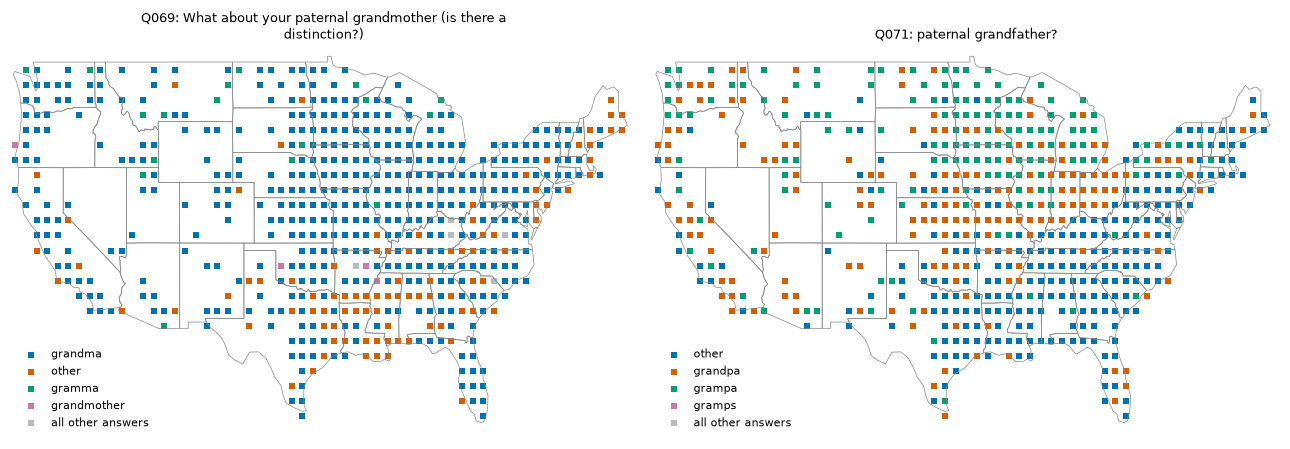

In [17]:
#map relationship between questions
import textwrap
def modal_map(q, ax, top=4, min_n=5):
    d = ling_clean.dropna(subset=[q]).copy()
    lab = answers(q)
    keep_ans = d[q].value_counts().index[:top]
    d['clat'], d['clon'] = np.floor(d['lat']), np.floor(d['long'])
    g = d.groupby(['clat', 'clon'])[q]
    cells = pd.DataFrame({'n': g.size(), 'mode': g.agg(lambda s: s.value_counts().index[0])}).reset_index()
    cells = cells[cells['n'] >= min_n]
    state_df.boundary.plot(ax=ax, color='#888888', linewidth=0.5)
    for i, k in enumerate(keep_ans):
        s = cells[cells['mode'] == k]
        ax.scatter(s['clon'] + .5, s['clat'] + .5, s=22, marker='s', color=OI[i], label=textwrap.fill(lab[k], 24), lw=0)
    s = cells[~cells['mode'].isin(keep_ans)]
    ax.scatter(s['clon'] + .5, s['clat'] + .5, s=22, marker='s', color='#BBBBBB', label='all other answers', lw=0)
    ax.set_xlim(-125, -66); ax.set_ylim(24, 50); ax.axis('off')
    ax.legend(loc='lower left', frameon=False, fontsize=8)

import textwrap
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, q in zip(axes, (QA, QB)):
    modal_map(q, ax); ax.set_title(f'{q}: ' + textwrap.fill(quest[int(q[1:])], 60), fontsize=9)
plt.tight_layout(); plt.show()

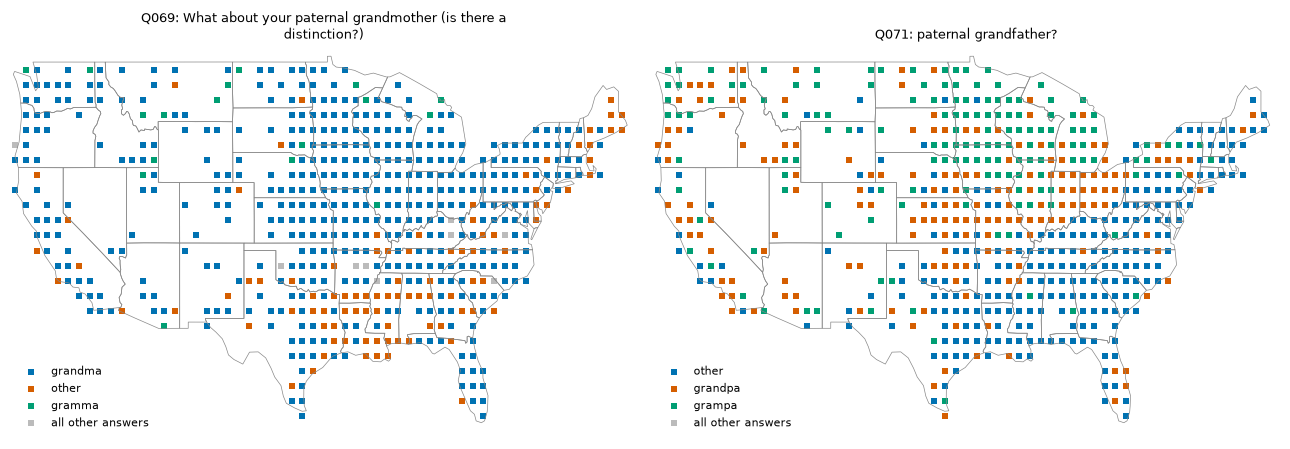

saved ../report/figures/maps_Q069_Q071.png


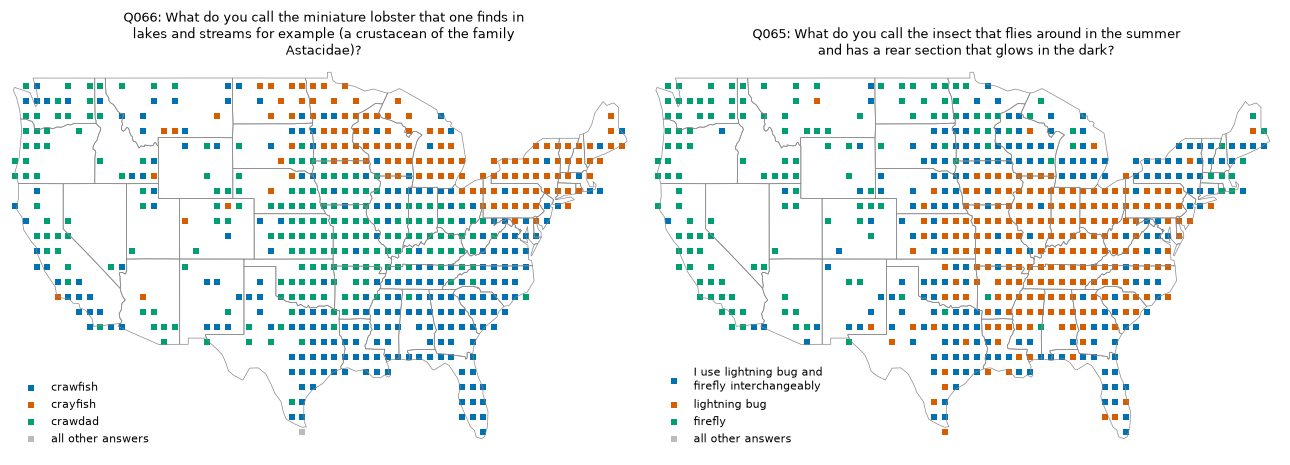

saved ../report/figures/maps_Q066_Q065.png


In [18]:
#question pairs for report and save to figures
import os
FIG_DIR = '../report/figures'
os.makedirs(FIG_DIR, exist_ok=True)

PAIRS = [(69, 71), (66, 65)] 

for a, b in PAIRS:
    qa, qb = f'Q{a:03d}', f'Q{b:03d}'
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    for ax, q in zip(axes, (qa, qb)):
        modal_map(q, ax, top=3)
        ax.set_title(f'{q}: ' + textwrap.fill(quest[int(q[1:])], 60), fontsize=9)
    plt.tight_layout()
    path = f'{FIG_DIR}/maps_{qa}_{qb}.png'
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    print('saved', path)

In [19]:
#interactive maps with plotly to inspect the data in each square on the map
import plotly.graph_objects as go

bx, by = [], []
for geom in state_df.geometry:
    for poly in (geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]):
        x, y = poly.exterior.xy
        bx += list(x) + [None]; by += list(y) + [None]

def plotly_modal_map(q, top=3, min_n=5):
    d = ling_clean.dropna(subset=[q]).copy()
    d[q] = d[q].astype(int)
    lab = answers(q)
    d['clat'], d['clon'] = np.floor(d['lat']) + .5, np.floor(d['long']) + .5    

    counts = d.groupby(['clat', 'clon', q]).size().unstack(fill_value=0)       
    n = counts.sum(axis=1)
    counts, n = counts[n >= min_n], n[n >= min_n]                              
    shares = counts.div(n, axis=0)
    mode, mode_share = shares.idxmax(axis=1), shares.max(axis=1)             

    def hover(cell):
        s = shares.loc[cell].sort_values(ascending=False)
        s = s[s > 0].head(5)
        return f'n = {n.loc[cell]}<br>' + '<br>'.join(f'{lab[k]}: {v:.0%}' for k, v in s.items())

    top_codes = list(d[q].value_counts().index[:top])
    groups = [(lab[k], OI[i], mode == k) for i, k in enumerate(top_codes)]
    groups.append(('all other answers', '#BBBBBB', ~mode.isin(top_codes)))

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=bx, y=by, mode='lines', line=dict(color='#888888', width=0.7),
                             hoverinfo='skip', showlegend=False))
    for name, color, mask in groups:
        cells = mode[mask].index
        fig.add_trace(go.Scatter(
            x=[c[1] for c in cells], y=[c[0] for c in cells], name=name, mode='markers',
            marker=dict(symbol='square', size=10, color=color, opacity=(0.25 + 0.75 * mode_share[mask]).values),
            text=[hover(c) for c in cells], hovertemplate='%{text}<extra>' + name + '</extra>'))
    fig.update_layout(
        title=dict(text=f'{q}: ' + '<br>'.join(textwrap.wrap(quest[int(q[1:])], 80)), font=dict(size=13)),
        xaxis=dict(range=[-125, -66], visible=False),
        yaxis=dict(range=[24, 50], visible=False, scaleanchor='x', scaleratio=1.25),   # ~cos(37 deg) aspect
        plot_bgcolor='white',
        legend=dict(title='Most common answer'), margin=dict(l=0, r=0, t=80, b=0), height=520, width=900)
    return fig

#save each map as a standalone .html (plotly.min.js is written once next to them) so it opens without running the notebook
import os
FIG_DIR = '../report/figures'
os.makedirs(FIG_DIR, exist_ok=True)

for n_ in (68, 69, 66, 65):
    fig = plotly_modal_map(f'Q{n_:03d}')
    fig.write_html(f'{FIG_DIR}/map_Q{n_:03d}.html', include_plotlyjs='directory')
    fig.show()

In [20]:
#relationship between one pair of the two questions
d = ling_clean.dropna(subset=[QA, QB])
ta, tb = d[QA].value_counts().index[:4], d[QB].value_counts().index[:4]
sub = d[d[QA].isin(ta) & d[QB].isin(tb)]
ct = pd.crosstab(sub[QA].map(answers(QA)), sub[QB].map(answers(QB)))
print('counts:'); display(ct)
print(f'P({QB} | {QA}):'); display(ct.div(ct.sum(axis=1), axis=0).round(2))
chi2, p, *_ = chi2_contingency(ct)
print(f'chi-square p = {p:.2g}, Cramer V = {np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1))):.3f}')

counts:


Q071,grampa,gramps,grandpa,other
Q069,,,,
gramma,5180,32,496,762
grandma,5595,128,11522,3348
grandmother,254,35,911,1596
other,1045,131,1182,7789


P(Q071 | Q069):


Q071,grampa,gramps,grandpa,other
Q069,,,,
gramma,0.80,0.00,0.08,0.12
grandma,0.27,0.01,0.56,0.16
grandmother,0.09,0.01,0.33,0.57
other,0.10,0.01,0.12,0.77


chi-square p = 0, Cramer V = 0.423


### Dimensionality Reduction

In [21]:
#binary encoding of answers
blocks = []
for c in qcols:
    n_opts = len(question_data[f'ans.{int(c[1:])}'])
    b = pd.get_dummies(pd.Categorical(ling_clean[c].astype('Int64'), categories=range(1, n_opts + 1)), dtype=np.uint8)
    b.columns = [f'{c}_{k}' for k in range(1, n_opts + 1)]   # e.g. Q066_5 = answer 5 to Q066
    b.index = ling_clean.index
    blocks.append(b)
X_bin = pd.concat(blocks, axis=1)      # a skipped question becomes all zeros in its block


In [22]:
#check the binary encoding
print('shape:', X_bin.shape, '(expect p = 468)')
assert X_bin.shape[1] == 468
n_answered = len(qcols) - ling_clean['n_skipped']
print('rows whose number of 1s != number of answered questions:', (X_bin.sum(axis=1) != n_answered).sum())
freq = X_bin.mean()
print('options nobody chose in the cleaned data:', (freq == 0).sum(), '| options chosen by < 0.1% of respondents:', (freq < 0.001).sum())


shape: (44995, 468) (expect p = 468)
rows whose number of 1s != number of answered questions: 0
options nobody chose in the cleaned data: 0 | options chosen by < 0.1% of respondents: 39


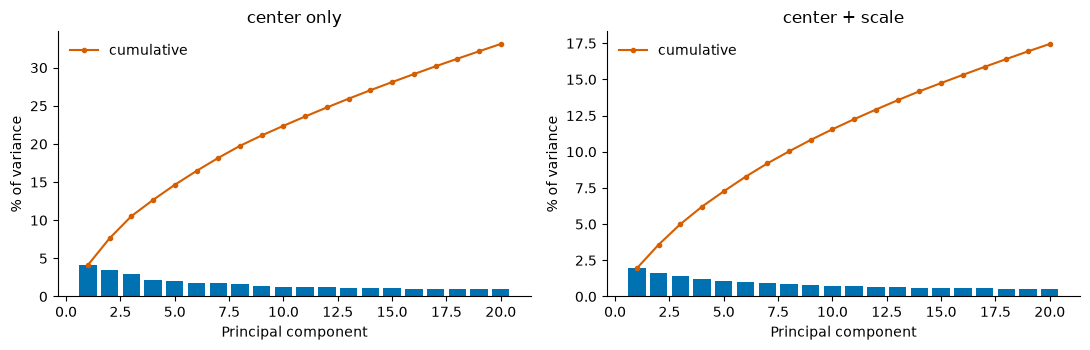

PC1-PC4 % variance, center only:    [4.1 3.5 2.9 2.1]
PC1-PC4 % variance, center + scale: [1.9 1.6 1.4 1.2]


In [23]:
#centering and scaling
from sklearn.decomposition import PCA

Xv = X_bin.values.astype(float)
Xc = Xv - Xv.mean(axis=0)                               # center only
sd = Xc.std(axis=0); sd[sd == 0] = 1                    # (guard: options nobody chose have sd = 0)
Xz = Xc / sd                                            # center + scale

pca_c = PCA(n_components=20, random_state=0).fit(Xc)
pca_z = PCA(n_components=20, random_state=0).fit(Xz)
S_c, S_z = pca_c.transform(Xc), pca_z.transform(Xz)    # scores: one row per respondent

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, pca, name in zip(ax, (pca_c, pca_z), ('center only', 'center + scale')):
    r = pca.explained_variance_ratio_
    a.bar(range(1, 21), r * 100, color=OI[0])
    a.plot(range(1, 21), np.cumsum(r) * 100, color=OI[1], marker='o', ms=3, label='cumulative')
    a.set_xlabel('Principal component'); a.set_ylabel('% of variance'); a.set_title(name); a.legend(frameon=False)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/pca_scree.png', dpi=200, bbox_inches='tight'); plt.show()
print('PC1-PC4 % variance, center only:   ', (pca_c.explained_variance_ratio_[:4] * 100).round(1))
print('PC1-PC4 % variance, center + scale:', (pca_z.explained_variance_ratio_[:4] * 100).round(1))


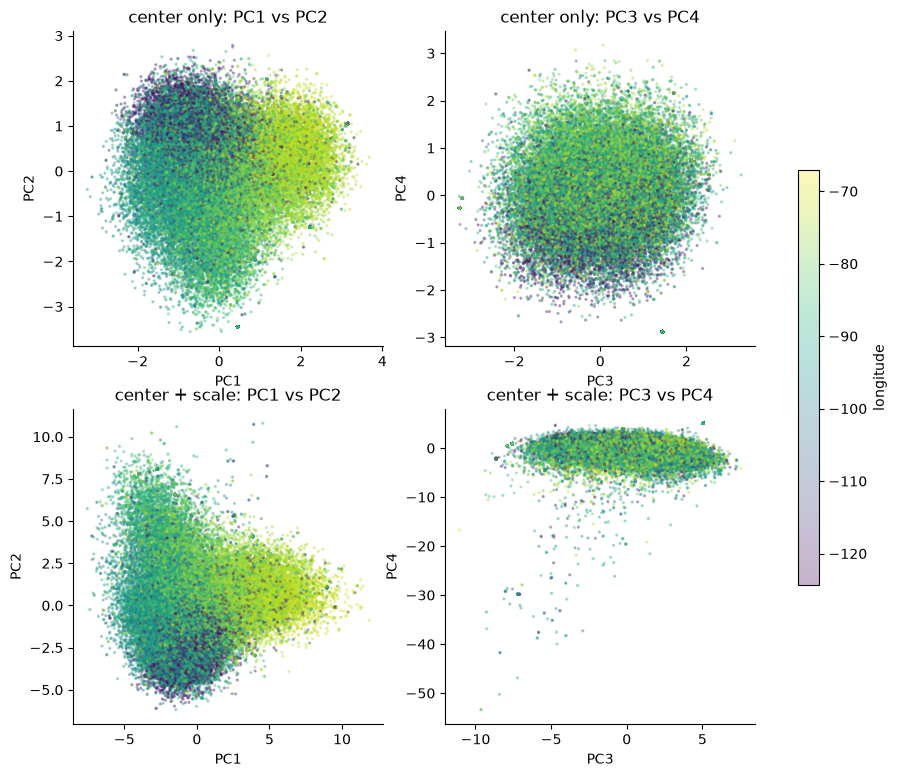

In [24]:
#PC scatter plots, one dot per respondent, colored by longitude (west = dark, east = light)
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, (S, name) in zip(axes, ((S_c, 'center only'), (S_z, 'center + scale'))):
    for a, (i, j) in zip(row, ((0, 1), (2, 3))):
        sc = a.scatter(S[:, i], S[:, j], c=ling_clean['long'], s=2, alpha=0.3, cmap='viridis', rasterized=True)
        a.set_xlabel(f'PC{i + 1}'); a.set_ylabel(f'PC{j + 1}'); a.set_title(f'{name}: PC{i + 1} vs PC{j + 1}')
fig.colorbar(sc, ax=axes, shrink=0.6, label='longitude')
plt.savefig(f'{FIG_DIR}/pca_scatter.png', dpi=200, bbox_inches='tight'); plt.show()


In [25]:
#which answers drive PC1 and PC2 (center only)
cols = X_bin.columns
for k in (0, 1):
    load = pd.Series(pca_c.components_[k], index=cols)
    top = load.reindex(load.abs().sort_values(ascending=False).index).head(8)
    print(f'PC{k + 1}:')
    for name, v in top.items():
        q_, code = name.split('_')
        print(f'   {v:+.2f}  {q_}: {answers(q_)[int(code)]}')


PC1:
   +0.27  Q073: sneakers
   -0.24  Q073: tennis shoes
   +0.20  Q105: soda
   +0.19  Q080: sunshower
   -0.18  Q080: I have no term or expression for this
   -0.17  Q105: pop
   -0.17  Q106: tp'ing
   +0.16  Q056: unacceptable
PC2:
   +0.25  Q076: kitty-corner
   -0.24  Q076: catty-corner
   -0.21  Q103: water fountain
   -0.19  Q050: y'all
   +0.18  Q103: drinking fountain
   -0.16  Q071: other
   -0.16  Q089: yes
   -0.16  Q105: coke


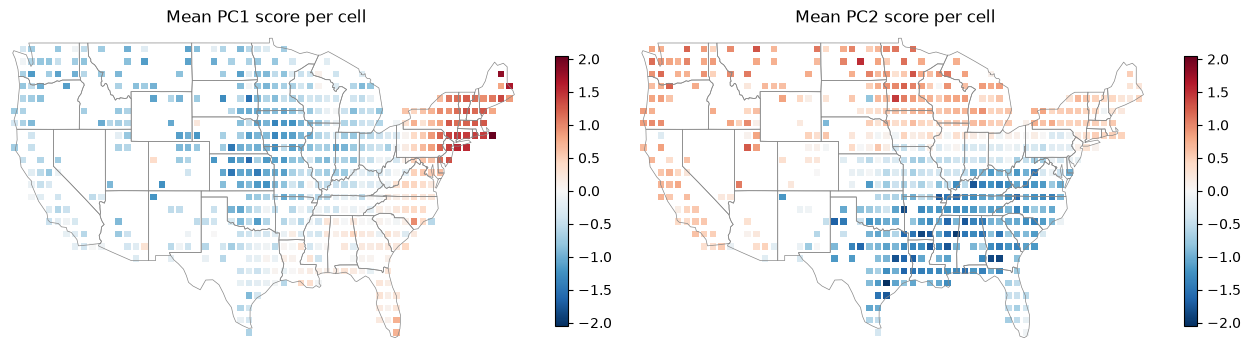

In [26]:
#average PC score in each 1x1 degree cell (center only), smooth geographic gradients = PCs are picking up regional dialect
d = ling_clean[['lat', 'long']].copy()
d['PC1'], d['PC2'] = S_c[:, 0], S_c[:, 1]
d['clat'], d['clon'] = np.floor(d['lat']) + .5, np.floor(d['long']) + .5
cell = d.groupby(['clat', 'clon']).agg(PC1=('PC1', 'mean'), PC2=('PC2', 'mean'), n=('PC1', 'size')).reset_index()
cell = cell[cell['n'] >= 5]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for a, pc in zip(axes, ('PC1', 'PC2')):
    state_df.boundary.plot(ax=a, color='#888888', linewidth=0.5)
    lim = cell[pc].abs().max()
    sc = a.scatter(cell['clon'], cell['clat'], c=cell[pc], cmap='RdBu_r', vmin=-lim, vmax=lim, s=22, marker='s', lw=0)
    a.set_xlim(-125, -66); a.set_ylim(24, 50); a.axis('off'); a.set_title(f'Mean {pc} score per cell')
    plt.colorbar(sc, ax=a, shrink=0.6)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/pca_maps.png', dpi=200, bbox_inches='tight'); plt.show()


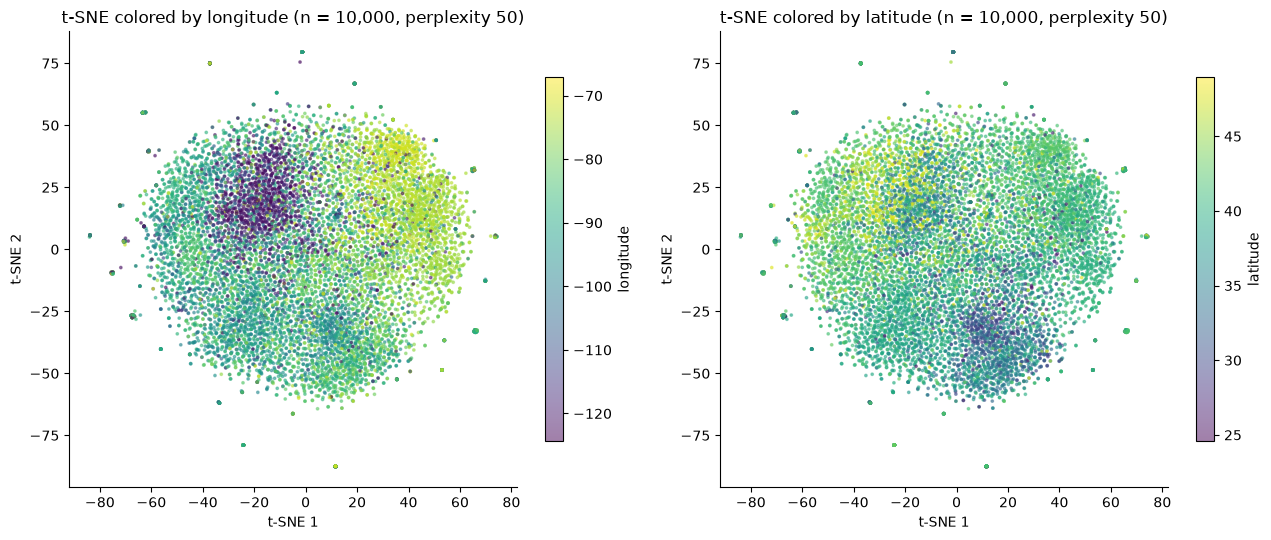

In [27]:
#t-SNE
from sklearn.manifold import TSNE

N_TSNE = 10_000          # lower this if it is too slow
PERPLEXITY = 50          # roughly the number of neighbors each point 'sees'; try 30 / 100 too
rng = np.random.RandomState(0)
idx = rng.choice(len(Xc), N_TSNE, replace=False)

pcs50 = PCA(n_components=50, random_state=0).fit_transform(Xc)[idx]
emb = TSNE(n_components=2, perplexity=PERPLEXITY, init='pca', random_state=0, n_jobs=-1).fit_transform(pcs50)

samp = ling_clean.iloc[idx]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for a, col, lab in zip(axes, ('long', 'lat'), ('longitude', 'latitude')):
    sc = a.scatter(emb[:, 0], emb[:, 1], c=samp[col], s=3, alpha=0.5, cmap='viridis', rasterized=True)
    a.set_xlabel('t-SNE 1'); a.set_ylabel('t-SNE 2'); a.set_title(f't-SNE colored by {lab} (n = {N_TSNE:,}, perplexity {PERPLEXITY})')
    plt.colorbar(sc, ax=a, label=lab, shrink=0.8)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/tsne.png', dpi=200, bbox_inches='tight'); plt.show()


### Clustering

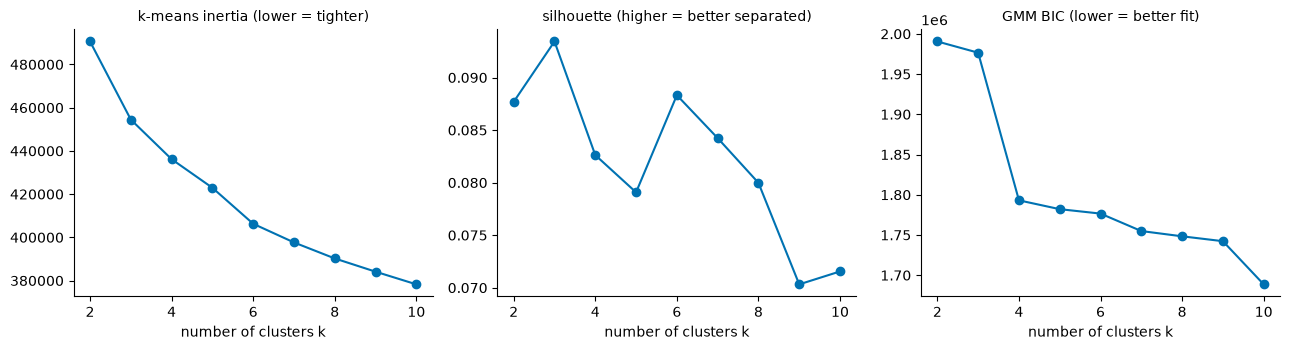

silhouette by k: {2: np.float64(0.088), 3: np.float64(0.093), 4: np.float64(0.083), 5: np.float64(0.079), 6: np.float64(0.088), 7: np.float64(0.084), 8: np.float64(0.08), 9: np.float64(0.07), 10: np.float64(0.072)}


In [28]:
#choose a number of clusters
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

Z = S_c[:, :20]                                   # respondents x 20 PCs
sil_idx = np.random.RandomState(0).choice(len(Z), 5000, replace=False)   # silhouette is slow, use a sample
ks = range(2, 11)
inertia, sil, bic = [], [], []
for k in ks:
    km_ = KMeans(k, n_init=5, random_state=0).fit(Z)
    inertia.append(km_.inertia_)
    sil.append(silhouette_score(Z[sil_idx], km_.labels_[sil_idx]))
    bic.append(GaussianMixture(k, covariance_type='diag', n_init=2, random_state=0).fit(Z).bic(Z))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for a, y, t in zip(ax, (inertia, sil, bic), ('k-means inertia (lower = tighter)', 'silhouette (higher = better separated)', 'GMM BIC (lower = better fit)')):
    a.plot(list(ks), y, marker='o', color=OI[0]); a.set_xlabel('number of clusters k'); a.set_title(t, fontsize=10)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/cluster_choose_k.png', dpi=200, bbox_inches='tight'); plt.show()
print('silhouette by k:', dict(zip(ks, np.round(sil, 3))))


In [29]:
#fitting
from scipy.optimize import linear_sum_assignment

K = 3
km_lab = KMeans(K, n_init=20, random_state=0).fit_predict(Z)
gmm = GaussianMixture(K, covariance_type='diag', n_init=5, random_state=0).fit(Z)
gmm_raw = gmm.predict(Z)
post = gmm.predict_proba(Z).max(axis=1)           # how sure the GMM is about each respondent

# GMM cluster numbers are arbitrary: relabel them to best match k-means so the colors line up
cm = pd.crosstab(km_lab, gmm_raw).reindex(columns=range(K), fill_value=0).values
r_, c_ = linear_sum_assignment(-cm)
remap = {c: r for r, c in zip(r_, c_)}
gmm_lab = np.array([remap[g] for g in gmm_raw])

print('k-means cluster sizes:', np.bincount(km_lab))
print('GMM cluster sizes:    ', np.bincount(gmm_lab))
print('agreement between methods (adjusted Rand index):', round(adjusted_rand_score(km_lab, gmm_lab), 3))
print('share of respondents the GMM is < 80% sure about:', round((post < 0.8).mean(), 3))


k-means cluster sizes: [13098 19100 12797]
GMM cluster sizes:     [11445 19847 13703]
agreement between methods (adjusted Rand index): 0.811
share of respondents the GMM is < 80% sure about: 0.233


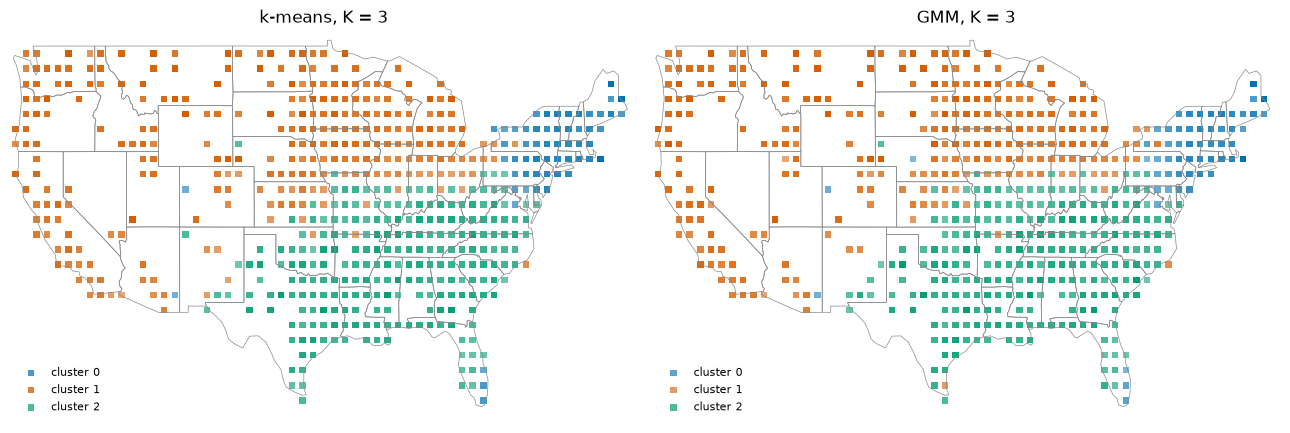

In [30]:
#clusters folllowing georgraphy
def cluster_map(ax, lab, title, min_n=5):
    d = pd.DataFrame({'clat': np.floor(ling_clean['lat']).values + .5, 'clon': np.floor(ling_clean['long']).values + .5, 'c': lab})
    counts = d.groupby(['clat', 'clon', 'c']).size().unstack(fill_value=0)
    n = counts.sum(axis=1)
    counts, n = counts[n >= min_n], n[n >= min_n]
    share = counts.div(n, axis=0)
    mode, mode_share = share.idxmax(axis=1), share.max(axis=1)
    state_df.boundary.plot(ax=ax, color='#888888', linewidth=0.5)
    for k in range(K):
        cells_ = mode[mode == k].index
        ax.scatter([c[1] for c in cells_], [c[0] for c in cells_], s=22, marker='s', color=OI[k], lw=0,
                   alpha=(0.25 + 0.75 * mode_share[mode == k]).values, label=f'cluster {k}')
    ax.set_xlim(-125, -66); ax.set_ylim(24, 50); ax.axis('off'); ax.set_title(title)
    ax.legend(loc='lower left', frameon=False, fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
cluster_map(axes[0], km_lab, f'k-means, K = {K}')
cluster_map(axes[1], gmm_lab, f'GMM, K = {K}')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/cluster_maps.png', dpi=200, bbox_inches='tight'); plt.show()


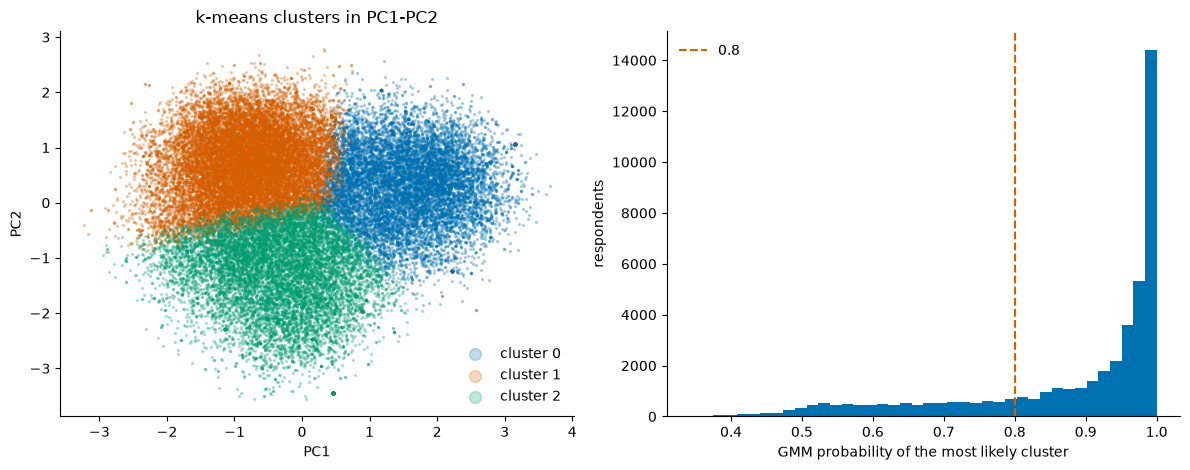

In [31]:
#clusters separately or continuum
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
for k in range(K):
    m = km_lab == k
    ax[0].scatter(S_c[m, 0], S_c[m, 1], s=2, alpha=0.25, color=OI[k], label=f'cluster {k}', rasterized=True)
ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2'); ax[0].set_title('k-means clusters in PC1-PC2')
ax[0].legend(markerscale=6, frameon=False)
ax[1].hist(post, bins=40, color=OI[0]); ax[1].axvline(0.8, color=OI[1], ls='--', label='0.8')
ax[1].set_xlabel('GMM probability of the most likely cluster'); ax[1].set_ylabel('respondents'); ax[1].legend(frameon=False)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/cluster_continuum.png', dpi=200, bbox_inches='tight'); plt.show()


In [32]:
#which questions separate clusters
from scipy.stats import chi2_contingency

clu = pd.Series(km_lab, index=ling_clean.index, name='cluster')
vals = {}
for q in qcols:
    m = ling_clean[q].notna()
    t = pd.crosstab(clu[m], ling_clean.loc[m, q].astype(int))
    vals[q] = np.sqrt(chi2_contingency(t, correction=False)[0] / (t.values.sum() * (min(t.shape) - 1)))
qv = pd.Series(vals).sort_values(ascending=False)
top = pd.DataFrame({"Cramer's V": qv.head(10).round(2), 'question': [quest[int(q[1:])][:75] for q in qv.head(10).index]})
display(top)

print()
overall = X_bin.mean()
for k in range(K):
    diff = (X_bin[clu == k].mean() - overall).sort_values(ascending=False).head(6)
    print(f'cluster {k} (n = {(clu == k).sum():,}): answers most over-represented (share in cluster vs overall)')
    for name, dv in diff.items():
        q_, code = name.split('_')
        print(f'   {q_}: {answers(q_)[int(code)]:30s} {X_bin.loc[clu == k, name].mean():.0%} vs {overall[name]:.0%}')


,Cramer's V,question
Q105,0.49,What is your generic term for a sweetened carbonated beverage?
Q073,0.49,"What is your *general* term for the rubber-soled shoes worn in gym class, f"
Q076,0.42,What term do you use to refer to something that is across both streets from
Q106,0.42,What do you call the act of covering a house or area in front of a house wi
Q050,0.41,What word(s) do you use to address a group of two or more people?
Q103,0.41,What do you call the thing from which you might drink water in a school?
Q080,0.36,What do you call it when rain falls while the sun is shining?
Q074,0.35,What do you call the little gray creature (that looks like an insect but is
Q099,0.34,Which of these terms do you prefer for the small road parallel to the highw
Q110,0.32,What do you call the night before Halloween?



cluster 0 (n = 13,098): answers most over-represented (share in cluster vs overall)
   Q073: sneakers                       89% vs 38%
   Q105: soda                           84% vs 47%
   Q080: sunshower                      61% vs 31%
   Q078: scrap paper                    52% vs 28%
   Q086: yes                            52% vs 28%
   Q095: New York City                  64% vs 43%
cluster 1 (n = 19,100): answers most over-represented (share in cluster vs overall)
   Q103: drinking fountain              64% vs 34%
   Q076: kitty-corner                   75% vs 47%
   Q105: pop                            52% vs 29%
   Q106: tp'ing                         82% vs 60%
   Q099: frontage road                  52% vs 32%
   Q080: I have no term or expression for this 75% vs 59%
cluster 2 (n = 12,797): answers most over-represented (share in cluster vs overall)
   Q076: catty-corner                   70% vs 34%
   Q050: y'all                          49% vs 18%
   Q103: water fountain   

### Stability

In [33]:
#Random starting points
start_lab, start_inertia = [], []
for seed in range(30):
    km_ = KMeans(K, n_init=1, random_state=seed).fit(Z)      #one initialization only
    start_lab.append(km_.labels_); start_inertia.append(km_.inertia_)
ari_start = np.array([adjusted_rand_score(km_lab, l) for l in start_lab])

print(f'ARI vs the section 9 solution over 30 random starts: min {ari_start.min():.3f}, median {np.median(ari_start):.3f}, max {ari_start.max():.3f}')
print('distinct inertia values among the starts (rounded):', len(set(np.round(start_inertia))), '| best:', round(min(start_inertia)), '| worst:', round(max(start_inertia)))


ARI vs the section 9 solution over 30 random starts: min 0.942, median 0.948, max 0.999
distinct inertia values among the starts (rounded): 5 | best: 454483 | worst: 454511


In [34]:
#bootstrap
B = 30
rng = np.random.RandomState(1)
ari_boot = np.zeros(B)
jac = np.zeros((B, K))                 #best-match Jaccard for each original cluster in each bootstrap
agree = np.zeros(len(Z))               #how often each respondent lands in their original cluster

for b in range(B):
    idx = rng.choice(len(Xv), len(Xv), replace=True)                 #resample respondents
    pca_b = PCA(n_components=20, random_state=0).fit(Xv[idx])       #redo PCA on the resample (centers itself)
    Zb = pca_b.transform(Xv)                                         #project ALL original respondents
    km_b = KMeans(K, n_init=5, random_state=b).fit(Zb[idx])         #cluster the resampled respondents
    lab_b = km_b.predict(Zb)                                         #assign every original respondent

    ari_boot[b] = adjusted_rand_score(km_lab, lab_b)
    cm = pd.crosstab(km_lab, lab_b).reindex(index=range(K), columns=range(K), fill_value=0).values
    jac[b] = (cm / (cm.sum(axis=1)[:, None] + cm.sum(axis=0)[None, :] - cm)).max(axis=1)
    r_, c_ = linear_sum_assignment(-cm)                              #match new cluster numbers to the original ones
    mapping = np.zeros(K, dtype=int); mapping[c_] = r_
    agree += (mapping[lab_b] == km_lab)
agree /= B

print(f'bootstrap ARI vs original: min {ari_boot.min():.3f}, median {np.median(ari_boot):.3f}, max {ari_boot.max():.3f}')
print('mean Jaccard per original cluster:', dict(enumerate(jac.mean(axis=0).round(2))))
print(f'respondents assigned to their original cluster in >= 90% of bootstraps: {(agree >= 0.9).mean():.1%}')


bootstrap ARI vs original: min 0.924, median 0.978, max 0.987
mean Jaccard per original cluster: {0: np.float64(0.98), 1: np.float64(0.98), 2: np.float64(0.98)}
respondents assigned to their original cluster in >= 90% of bootstraps: 96.5%


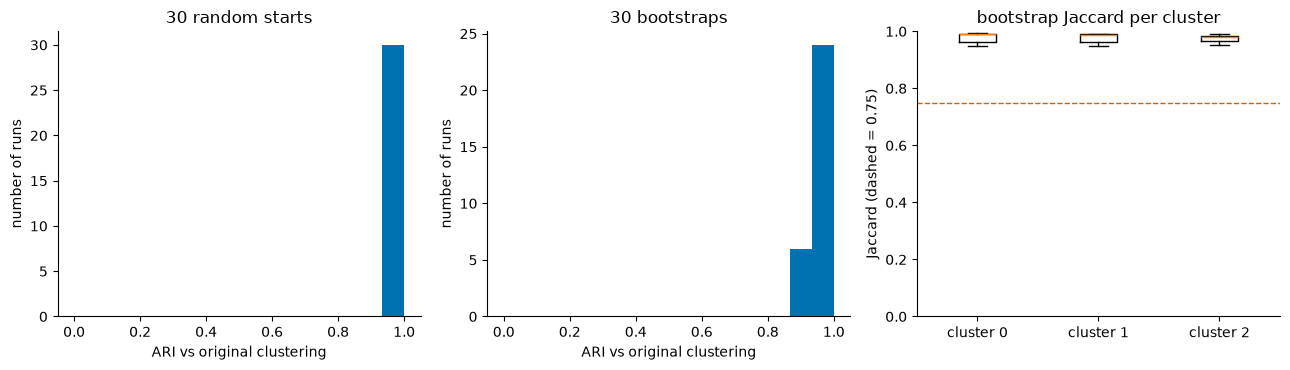

In [35]:
#figure
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].hist(ari_start, bins=15, range=(0, 1), color=OI[0]); ax[0].set_title('30 random starts'); ax[0].set_xlabel('ARI vs original clustering')
ax[1].hist(ari_boot, bins=15, range=(0, 1), color=OI[0]); ax[1].set_title(f'{B} bootstraps'); ax[1].set_xlabel('ARI vs original clustering')
ax[2].boxplot([jac[:, k] for k in range(K)], tick_labels=[f'cluster {k}' for k in range(K)])
ax[2].axhline(0.75, color=OI[1], ls='--', lw=1); ax[2].set_ylim(0, 1); ax[2].set_title('bootstrap Jaccard per cluster'); ax[2].set_ylabel('Jaccard (dashed = 0.75)')
for a in ax[:2]: a.set_ylabel('number of runs')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/stability.png', dpi=200, bbox_inches='tight'); plt.show()


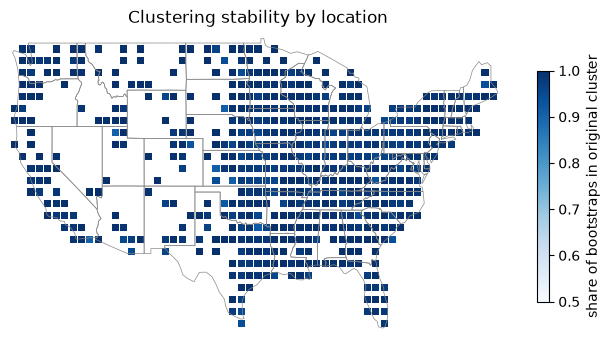

In [36]:
#cluster stability by location
d = pd.DataFrame({'clat': np.floor(ling_clean['lat']).values + .5, 'clon': np.floor(ling_clean['long']).values + .5, 'agree': agree})
cell = d.groupby(['clat', 'clon']).agg(agree=('agree', 'mean'), n=('agree', 'size')).reset_index()
cell = cell[cell['n'] >= 5]

fig, ax = plt.subplots(figsize=(8, 5))
state_df.boundary.plot(ax=ax, color='#888888', linewidth=0.5)
sc = ax.scatter(cell['clon'], cell['clat'], c=cell['agree'], cmap='Blues', vmin=0.5, vmax=1, s=26, marker='s', lw=0)
ax.set_xlim(-125, -66); ax.set_ylim(24, 50); ax.axis('off')
plt.colorbar(sc, ax=ax, shrink=0.6, label='share of bootstraps in original cluster')
ax.set_title('Clustering stability by location')
plt.savefig(f'{FIG_DIR}/stability_map.png', dpi=200, bbox_inches='tight'); plt.show()
